In [1]:
import pandas as pd
import numpy as np
import os, re, json, shutil, math, random
from sqlalchemy import create_engine
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.image as mpimg
from PIL import Image, ExifTags
from openai import AzureOpenAI
pd.set_option('display.max_columns', None)
from dataset.queries.queries import diagnosis_cn, roi_cn, num_cn, cls_cn
from dateutil import parser
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# Basic Preprocessing

In [5]:
def to_patient_info(s):
    parts = s.split('-')
    patient_id = int(parts[0].replace('患者', '').strip()) if len(parts) > 0 else None
    age = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else None
    gender = '男' if '男' in s else ('女' if '女' in s else '')
    return {'患者': patient_id, '年龄': age, '性别': gender}
    
def to_time(s):
    s = re.sub(' +',' ', s.strip())
    s = re.sub('[:._： ]', '-', s)
    s = re.sub('-+','-', s)
    s = re.split('——|——', s)[0]
    if len(s) < 11: s = s + '-0-0'
    try: return datetime.strptime(s, "%Y-%m-%d-%H-%M")
    except: return None

def generate_checkup_id(row):
    patient_id = row['患者']
    checkup_time = row['时间']
    checkup_time_str = checkup_time.strftime("%y-%m-%d-%H-%M")
    return f"{patient_id}-{checkup_time_str}"

In [1]:
image_size=4000
dir_data = 'D:/datasets/dental_doctor_raw'
dir_dataset = f'D:/datasets/dental_dataset_{image_size}'
dir_images_new, dir_xrays_new, dir_screenshots_new=f'{dir_dataset}/照片', f'{dir_dataset}/X片', f'{dir_dataset}/病历'
if not os.path.exists(dir_images_new): os.makedirs(dir_images_new)
if not os.path.exists(dir_xrays_new): os.makedirs(dir_xrays_new)
if not os.path.exists(dir_screenshots_new): os.makedirs(dir_screenshots_new)
    
chunks = os.listdir(dir_data)
ds = []
txt = pd.DataFrame()
no_checkups_folder_ds=[]
for chunk_count, chunk in enumerate(chunks, start=1):
    dir_chunk = f'{dir_data}/{chunk}'
    folders = [loc for loc in os.listdir(dir_chunk) if os.path.isdir(f'{dir_chunk}/{loc}')]
    dir_summary = f'{dir_chunk}/{folders[0]}'
    if '牙科数据_电子病历' not in dir_summary: continue
    dir_patients = folders[1:]
    summary_file = [f for f in os.listdir(f'{dir_summary}') if '牙科病历.xlsx' in f][0]
    df_chunk = pd.read_excel(f'{dir_summary}/{summary_file}', sheet_name=0)
    txt=pd.concat([txt, df_chunk])
    print(chunk_count,':  ', chunk, '=>', len(df_chunk))
    for patient in dir_patients:
        patient_info=to_patient_info(patient)
        dir_patient = f'{dir_chunk}/{patient}'
        checkups = os.listdir(dir_patient)
        checkups = [checkup for checkup in checkups if os.path.isdir(f'{dir_patient}/{checkup}')]
        for checkup in checkups:
            dir_checkup = f'{dir_patient}/{checkup}'
            checkup_time = to_time(checkup)
            if checkup_time:
                patient_info['时间']=checkup_time
                checkup_id=generate_checkup_id(patient_info)
            else:
                no_checkups_folder_ds.append(patient_info)
                continue
            images={}
            image_type_to_dir = {'照片': dir_images_new,'X片': dir_xrays_new,'病历': dir_screenshots_new} 
            for image_type, dist_dir in image_type_to_dir.items():
                dir_images_old = f'{dir_checkup}/{image_type}'
                if not os.path.exists(dir_images_old): continue
                files = [file for file in os.listdir(dir_images_old) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
                images_one_type = []
                for image_count, file in enumerate(files, start=1):
                    new_file_name = f"{checkup_id}-{image_count}"
                    images_one_type.append(new_file_name)

# ******************************************************************************************                   
                    dist_url = os.path.join(dist_dir, f"{new_file_name}.jpg")
                    if not os.path.exists(dist_url):
                        source_url = os.path.join(dir_images_old, file)
                        try:
                            with Image.open(source_url) as img: 
                                exif = img._getexif()
                                if exif:
                                    orientation_key = next((k for k, v in ExifTags.TAGS.items() if v == 'Orientation'), None)
                                    if orientation_key and orientation_key in exif:
                                        orientation = exif[orientation_key]
                                        if orientation == 3: img = img.rotate(180, expand=True)
                                        elif orientation == 6: img = img.rotate(270, expand=True)
                                        elif orientation == 8: img = img.rotate(90, expand=True)
                                if(image_type=='照片'):
                                    ratio = min(image_size / img.width, image_size / img.height)
                                    new_size = (int(img.width * ratio), int(img.height * ratio))
                                    img = img.resize(new_size, Image.LANCZOS)
                                img=img.convert('RGB')
                                img.save(dist_url, 'JPEG') 
                        except Exception as e: pass
# ******************************************************************************************                   
                
                images['screenshots' if image_type=='病历' else image_type]=','.join(images_one_type)        
            row={**{'checkup_id':checkup_id,'时间': checkup_time}, **patient_info, **images}
            ds.append(row)
ds_df = pd.DataFrame(ds).sort_values(by=['患者','时间'])
no_checkups=pd.DataFrame(no_checkups_folder_ds)
txt['患者'] = txt['患者'].apply(lambda x: int(x.replace('患者','').strip()))

In [2]:
df=ds_df
df_txt=txt.sort_values(by=['患者','时间'])
df_txt.to_csv(f'dataset/dental_dataset_txt.csv', encoding='utf-8-sig', index=False)
print('df_txt:',len(df_txt))

df_txt['时间'] = pd.to_datetime(df_txt['时间'], errors='coerce')
df_txt_invalid_time=df_txt[df_txt['时间'].isna()]
df_txt = df_txt.dropna(subset=['时间'])
df_txt['checkup_id'] = df_txt.apply(generate_checkup_id, axis=1)
print('df_txt - after dropping invalid times:', len(df_txt))

df_txt_duplicates = df_txt[df_txt.duplicated(subset=['checkup_id'], keep=False)]
df_txt["non_empty_count"] = df_txt.notna().sum(axis=1)
df_txt = df_txt.sort_values(by="non_empty_count", ascending=False)
df_txt = df_txt.drop_duplicates(subset=["checkup_id"], keep="first").drop(columns="non_empty_count")

print('df_txt - after dropping duplicates:', len(df_txt))

df_merged = (
    pd.merge(df, df_txt.drop(columns=['患者','时间']), on="checkup_id", how="inner")
    .fillna('')
    .sort_values(by=['患者','时间'])
    .drop_duplicates(subset=["checkup_id"])
    .replace('/', '')
    .rename(columns={'初诊/复诊病历': '病历'})
)
df_merged.to_csv(f'dataset/dental_dataset.csv', encoding='utf-8-sig', index=False)

print('\ndf:',len(df))
print('df_merged:',len(df_merged))

df_missing =df[~df['checkup_id'].isin(df_merged['checkup_id'])].sort_values(by=['患者','时间'])
df_txt_missing =df_txt[~df_txt['checkup_id'].isin(df_merged['checkup_id'])].sort_values(by=['患者','时间'])

df_txt_invalid_time['error']='Invalid time format in the Excel file'
df_missing['error']='Have folder but missing in the Excel file'
df_txt_missing['error']='No folder'
df_txt_duplicates['error']='Duplicate'
no_checkups['error']='No checkup folder in patient folder'

df_errors=pd.concat([df_txt_invalid_time,df_missing,df_txt_missing,df_txt_duplicates,no_checkups]).fillna('')
df_errors=df_errors.sort_values(by=['患者','时间'])
df_errors=df_errors[['患者','时间','年龄','性别','error']]
df_errors = df_errors.drop_duplicates()
df_errors.to_csv(f'dataset/dental_dataset_errors.csv', encoding='utf-8-sig', index=False)
print('errors:', len(df_errors))

# Normalize Teeth Numbers

In [3]:
df = pd.read_csv('dataset/dental_dataset.csv').fillna('')
df_=df.copy()
def convert_teeth(match):
    s = match.group(0)
    s = re.sub(r'[\[\]]', ' ', s)
    s = re.sub(r' +', ' ', s.strip()).split()
    all_teeth = []
    for quarter, teeth in enumerate(s, start=1):
        quarter = str(quarter)
        if quarter == '3': quarter = '4'
        elif quarter == '4': quarter = '3'
        quarter_teeth = []
        if teeth == '0': continue
        for tooth in teeth:
            if tooth.isdigit(): quarter_teeth.append(quarter + tooth)
        all_teeth += quarter_teeth
    return ','.join(sorted(all_teeth)) + ('号牙齿' if len(all_teeth) > 0 else '')

def normalize_teeth(s):
    s = re.sub(r'(\[[0-9]+\]){2,}', convert_teeth, str(s))
    return s.strip(' ,，')

for c in df.columns[8:20]: df[c] = df[c].apply(lambda x: normalize_teeth(x))  
df.to_csv(f'dataset/dental_dataset_normalized_teeth.csv', encoding='utf-8-sig', index=False)
print(len(df))

# Translation

### GPT4o Azure API

In [ ]:
api_key='************************'
api_version="2024-02-15-preview"
azure_endpoint="https://australia1.openai.azure.com/"
model='Australia-gpt-4o'
client=AzureOpenAI(api_key=api_key, api_version=api_version, azure_endpoint=azure_endpoint) 
def chat(messages):
    response = client.chat.completions.create(
        model=model,
        temperature=0.4,
        max_tokens=4096,
        messages=messages,
        response_format={"type": "json_object"}
    )
    return response

In [ ]:
with open('prompts/pp-8-translation-1.txt', 'r', encoding='utf8') as f: 
    prompt=f.read()
system_message=[{"role":"system", "content": [{"type":"text", "text":prompt}]}]
df=pd.read_csv('dataset/dental_dataset_merged_with_old.txt', sep='\t').fillna('').sort_values(by='checkup_id')
df['checkup_id']=df['checkup_id'].astype(int)
tr=pd.DataFrame()
try:
    tr=pd.read_csv('dataset/dental_dataset_translated.txt', sep='\t').fillna('').sort_values(by='checkup_id')
    tr['checkup_id']=tr['checkup_id'].astype(int)
    done=tr.checkup_id.to_list()
    df=df[~df['checkup_id'].isin(done)]
except: pass
    
cols=list(df.columns)
df=df[[cols[0]]+cols[5:17]]
batch_size=10
temp_df=tr.copy()
if(len(temp_df)>0):temp_df['checkup_id']=temp_df['checkup_id'].astype(int)
for i in range(0, len(df), batch_size):
    batch = df[i:i + batch_size]
    batch_ids=[int(i) for i in batch.checkup_id.tolist()]
    content=[]
    for i, r in batch.iterrows():
        r=r.to_dict()
        item=''
        for key in r:
            if(r[key]!=''):
                item+=f'{key}: {r[key]}\n'
        content.append({'type': 'text', 'text': item})
        
    msg={"role":"user", "content":content}
    messages=system_message+[msg]
    try: 
        t1=time.time()
        response=chat(messages)
        res_df=pd.DataFrame(json.loads(response.choices[0].message.content))
        res_df['checkup_id']=batch_ids
        temp_df=pd.concat([temp_df, res_df])
        temp_df.to_csv('dataset/dental_dataset_pp1_trans_1.csv', encoding='utf-8-sig', index=False)
        print(round(time.time()-t1,1))
        display(res_df)   
    except: print('Error===========================')
    time.sleep(30)

# Extracting Diseases

### Check Frequency of each Disease

In [8]:
diseases_df=pd.read_excel('dataset/diseases.xlsx', sheet_name=0).fillna('')
dental_diseases=diseases_df['Disease in Dataset'].to_list()
normalize_to=diseases_df['Normalize To'].to_list()
classes=[c for c in sorted(set(normalize_to)) if c]
normalize={d:n for d,n in zip(dental_diseases,normalize_to) if n}
print('Diseases in Dataset:', len(dental_diseases))
print('Classes:', len(classes))
print('Normalized:', len(normalize))

df = pd.read_csv('dataset/dental_dataset_normalized_teeth.csv').fillna('')
print('DF:',len(df))
cols=list(df.columns)[8:]
c = '\n'.join('\n'.join(f"{col}: {row[col]}" for col in cols if row[col]) + '\n' + ('_' * 80) for _, row in df.iterrows())
print('Content:', f"{round(len(c)/1000000,2)} M")
# with open ('dataset/content.txt', 'w', encoding='utf8') as f: f.write(c)

condition_counts = {condition: c.count(condition) for condition in dental_diseases}
sorted_condition = dict(sorted(condition_counts.items(), key=lambda item: item[1], reverse=True))
# print('')
# for condition, count in sorted_condition.items():
#     print(f"{condition}\t{normalized.get(condition,'')}\t{count}")

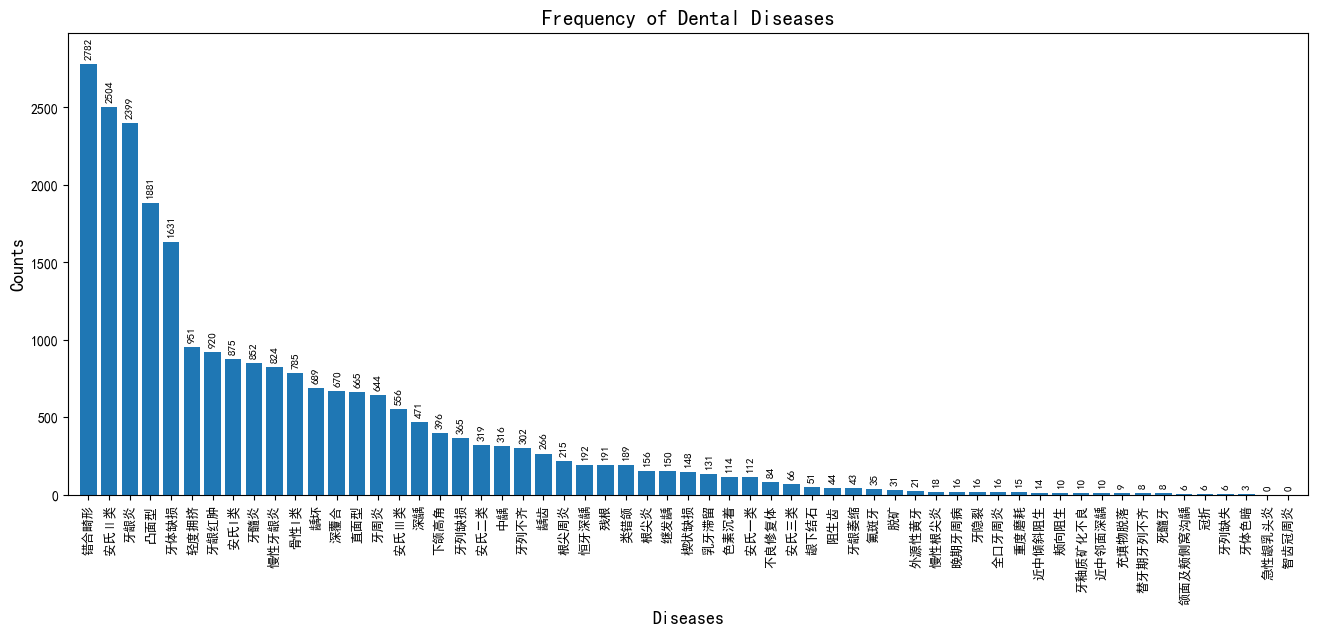

In [10]:
diseases = list(sorted_condition.keys())
counts = list(sorted_condition.values())
plt.figure(figsize=(16, 6))
bars = plt.bar(diseases, counts)
plt.xlabel('Diseases', fontsize=13)
plt.ylabel('Counts', fontsize=13)
plt.xticks(rotation=90, fontsize=9)
title=f'Frequency of Dental Diseases'
plt.title(title, fontsize=15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 30, f'{height}', ha='center', va='bottom', rotation=90, fontsize=8)
plt.margins(x=0.01)
plt.ylim(0,max(counts)+200)
plt.savefig(f'dataset/statistics/{title}.png', format='png', bbox_inches='tight')
plt.show()

### Diseases Normalization

In [11]:
ds=[]
for i, r in df.iterrows():
    r=r.to_dict()
    content=''
    diseases=[]
    for key in cols:
        if(r[key]!=''): content+=f'{key}: {r[key]}\n'
    for anomaly in normalize.keys():
        if(anomaly in content): diseases.append(anomaly)
    diseases=sorted(set([normalize[d] for d in diseases]))
    r['diseases']=','.join(diseases) if (len(diseases))>0 else ""
    ds.append(r)
ds_df=pd.DataFrame(ds)
ds_df.to_csv(f'dataset/dental_dataset_diseases.csv', encoding='utf-8-sig', index=False)

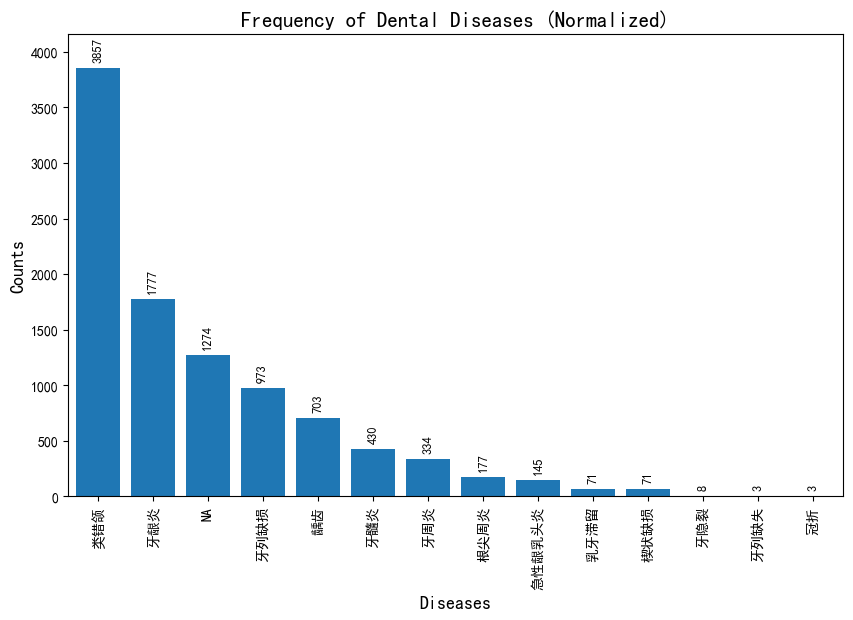

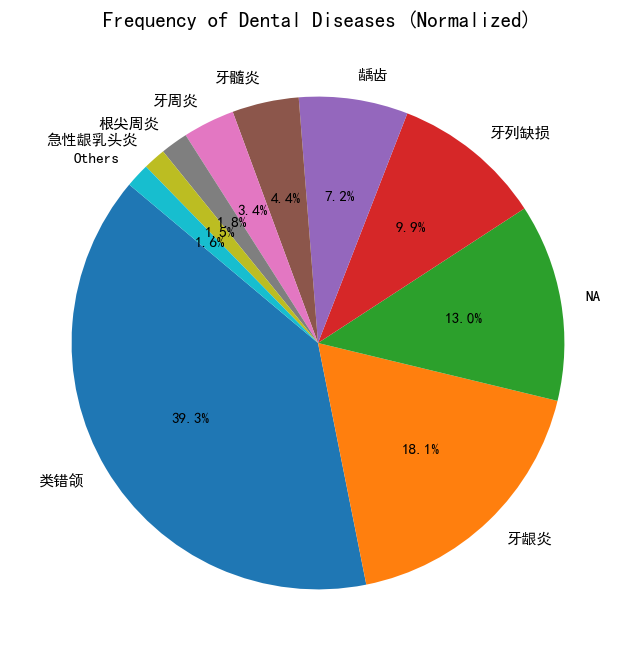

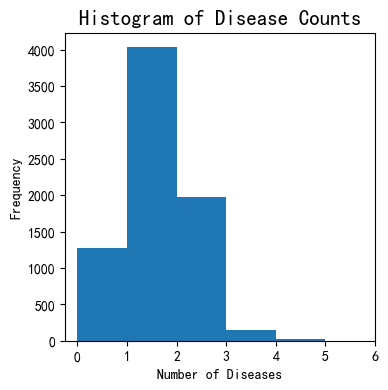

In [12]:
df=pd.read_csv(f'dataset/dental_dataset_diseases.csv').fillna('')
diseases_series = df['diseases'].str.split(',').explode()
disease_counts = diseases_series.value_counts().to_dict()
total_diseases_count=0
total_na=0
for k,v in disease_counts.items():
    if(k):total_diseases_count+=v
    else:total_na+=v
title=f'Frequency of Dental Diseases (Normalized)'
diseases = list(disease_counts.keys())
counts = list(disease_counts.values())
diseases[diseases.index('')]='NA'
plt.figure(figsize=(10, 6))
bars = plt.bar(diseases, counts)
plt.xlabel('Diseases', fontsize=13)
plt.ylabel('Counts', fontsize=13)
plt.xticks(rotation=90, fontsize=10)
plt.title(title, fontsize=15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height+50, f'{height}', ha='center', va='bottom', rotation=90, fontsize=9)
plt.margins(x=0.01)
plt.ylim(0,max(counts)+300)
plt.savefig(f'dataset/statistics/{title}-bar.png', format='png', bbox_inches='tight')
plt.show()

filtered_disease_counts = {k: v for k, v in disease_counts.items() if v >= 100}
filtered_disease_counts["Others"] = sum(v for k, v in disease_counts.items() if v < 100)
diseases = list(filtered_disease_counts.keys())
counts = list(filtered_disease_counts.values())
diseases[diseases.index('')]='NA'
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(counts,labels=diseases, autopct='%1.1f%%',startangle=140,textprops={'fontsize': 11})
plt.title(title, fontsize=15)
plt.savefig(f'dataset/statistics/{title}-pie.png', format='png', bbox_inches='tight')
plt.show()

title='Histogram of Disease Counts'
df['diseases_count'] = df['diseases'].apply(lambda x: len(x.split(',')) if x else 0)
plt.figure(figsize=(4, 4))
plt.hist(df['diseases_count'], bins=range(df['diseases_count'].max()))
plt.xlabel('Number of Diseases')
plt.ylabel('Frequency')
plt.title(title, fontsize=15)
plt.xticks(range(df['diseases_count'].max() + 1))
plt.savefig(f'dataset/statistics/{title}.png', format='png', bbox_inches='tight')
plt.show()

#### Patient Checkups

In [ ]:
df=pd.read_csv(f'dataset/dental_dataset_diseases.csv').fillna('')
print(len(df))
df=df[df['diseases']!='']
df=df[df['照片']!='']
print(len(df))
# conn = pymysql.connect(host='localhost', user='root', password='', charset='utf8', db='u655013255_dental')
# cur = conn.cursor()
# for i, row in df.iterrows():
#     row = row.to_dict()
#     sql = """
#     INSERT INTO `dentals` (
#         `checkup_id`, `时间`, `患者`, `年龄`, `性别`, `病历`, `主诉`, 
#         `现病史`, `既往史`, `检查`, `X线检查示`, `诊断`, `治疗方案`, `治疗建议`, 
#         `处理`, `医嘱`, `备注`, `照片`,`X片`,`screenshots`, `diseases`, `diseases_original`
#     ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
#     """
#     cur.execute(sql, (
#         row['checkup_id'], row['时间'], row['患者'], row['年龄'], row['性别'],
#         row['病历'], row['主诉'], row['现病史'], row['既往史'], row['检查'], 
#         row['X线检查示'], row['诊断'], row['治疗方案'], row['治疗建议'], 
#         row['处理'], row['医嘱'], row['备注'], row['照片'],row['X片'],row['screenshots'], row['diseases'], row['diseases']
#     ))

# conn.commit()

#### Diseases Classes

In [ ]:
# print(len(classes))
# conn = pymysql.connect(host='localhost', user='root', password='', charset='utf8', db='u655013255_dental')
# cur = conn.cursor()
# for disease in sorted(classes):
#     sql = "INSERT INTO `diseases` (`name`) VALUES (%s)"
#     cur.execute(sql, (disease))
# conn.commit()

# QA Queries

In [4]:
df=pd.read_csv('dataset/dental_dataset_roi.csv').fillna('')
df['年龄']=df['年龄'].apply(lambda x: int(x) if x else '')
def pp_queries(queries):
    queries_ = (queries * (len(df) // len(queries) + 1))[:len(df)]
    random.shuffle(queries_)
    return [str(q) for q in queries_]

df['qa_diagnosis']= pp_queries(diagnosis_cn) 
df['qa_roi']= pp_queries(roi_cn) 
df['qa_num']= pp_queries(num_cn) 
df['qa_cls']= pp_queries(cls_cn) 

def pp_cls(row):
    qa=eval(row[f'qa_cls'])
    diseases=row[f'diseases'].replace(',',', ').strip()
    if diseases: 
        qa['assistant']=diseases
        row[f'qa_cls']=str(qa)
    else:row[f'qa_cls']=''
    return row

def pp_num(row):
    ill_teeth=row['ill_teeth'].strip()
    for col in ['qa_num']:
        qa = eval(row[col])
        if ill_teeth: 
            qa['assistant'] = (qa['assistant'] + '：\n' if qa['assistant'] else '') + ill_teeth
            # qa['assistant'] = ill_teeth
            row[col] = str(qa)
        else:row[col]=''
    return row
    
def pp_roi(row):
    roi=row['roi'].replace(',',', ').strip()
    roi=roi.replace('BR','Bottom Right').replace('BL','Bottom Left').replace('TR','Top Right').replace('TL','Top Left')
    for col in ['qa_roi']:
        qa = eval(row[col])
        if roi: 
            qa['assistant'] = (qa['assistant'] + '：\n' if qa['assistant'] else '') + roi
            # qa['assistant'] = ill_teeth
            row[col] = str(qa)
        else:row[col]=''
    return row

def pp_diagnosis(row):
    input_cols=['年龄', '性别', '病历', '主诉', '现病史', '既往史']
    output_cols=['检查', '诊断', '治疗方案', '治疗建议', '医嘱', '备注']
    user_content='患者信息:\n\n'
    assistant_content=''
    for col in input_cols:
        if(row[col]): user_content+=f'{col}: {row[col]}\n'
    for col in output_cols:
        if(row[col]): assistant_content+=f'{col}: {row[col]}\n'
    
    qa = eval(row[f'qa_diagnosis'])
    qa['user'] = (qa['user'] + '\n' if qa['user'] else '') + user_content
    qa['assistant'] = assistant_content
    row[f'qa_diagnosis']=str(qa)
    return row    
    
df=df.apply(lambda x: pp_diagnosis(x), axis=1)
df=df.apply(lambda x: pp_cls(x), axis=1)
df=df.apply(lambda x: pp_num(x), axis=1)
df=df.apply(lambda x: pp_roi(x), axis=1)

df.to_csv(f'dataset/dental_dataset_qa.csv', encoding='utf-8-sig', index=False)
print(len(df))

7460


## Train-test Split

In [9]:
df=pd.read_csv(f'dataset/dental_dataset_qa.csv').fillna('').sort_values(by='checkup_id')
df['image_count'] = df['照片'].apply(lambda x: len(x.split(',')) if x else 0)
df["empty_count"] = df.iloc[:, 8:20].apply(lambda row: (row == '').sum() + row.isna().sum(), axis=1)

normalize_to=pd.read_excel('dataset/diseases.xlsx', sheet_name=0).fillna('')['Normalize To'].to_list()
classes=[c for c in sorted(set(normalize_to)) if c]

df=df.sample(frac=1,random_state=42)
df_test=pd.DataFrame()
for disease in classes:
    x = df[
        (df['image_count'] > 2) &
        (df['empty_count'] < 6 ) &
        (df['ill_teeth'] != "") &
        (df['diseases'].str.contains(disease, na=False))
    ]
    test_ratio=30
    threshold=int(test_ratio/100*len(x))
    test=x[:threshold]
    df_test=pd.concat([df_test,test.copy()])


df_test = df_test.drop_duplicates(subset='checkup_id')    
df_train = df[~df['checkup_id'].isin(df_test['checkup_id'])]
print('df:',len(df), len(df_train)+len(df_test))
print('train:',len(df_train))
print('test:',len(df_test))

df_train=df_train.drop(columns=['image_count','empty_count']) 
df_test=df_test.drop(columns=['image_count','empty_count']) 

df_train.to_csv(f'dataset/train_unique.csv', encoding='utf-8-sig', index=False)
df_test.to_csv(f'dataset/test_unique.csv', encoding='utf-8-sig', index=False)

df: 7460 7460
train: 6993
test: 467


## Augmentation

### Limit the number of images to a threshold

In [9]:
df_train=pd.read_csv(f'dataset/train_unique.csv')
df_test=pd.read_csv(f'dataset/test_unique.csv')

def limit_images(df):
    df=df.copy()
    df['照片']=df['照片'].apply(lambda x: str(x).split(','))
    max_images=8
    df1 = df[df['照片'].apply(len) <= max_images]
    df2 = df[df['照片'].apply(len) > max_images]
    ds=[]
    for i,r in df2.iterrows():
        r=r.to_dict()
        images=r['照片']
        thr=int(len(images)/2)+1
        random.seed(42)
        random.shuffle(images)
        images_1=images[:thr][:max_images]
        images_2=images[thr-1:][:max_images]
        r1,r2=r.copy(),r.copy()
        r1['照片']=images_1
        ds.append(r1)
        r2['照片']=images_2
        ds.append(r2)
    df3=pd.DataFrame(ds)
    return pd.concat([df1,df3])

print('train:',len(df_train))
print('test:',len(df_test))

df_train = limit_images(df_train)
df_test = limit_images(df_test)

print('\nAfter limiting images\n')
print('train:',len(df_train))
print('test:',len(df_test))

### Randomize images (No rotation)

In [10]:
images_min_len=3
def randomize_normal_images(images, seed):
    random.seed(seed);np.random.seed(seed) 
    random.shuffle(images)
    if(len(images)<=images_min_len):return images
    else:
        thr=random.choice(np.arange(images_min_len,len(images)))
        images=images[:thr]
        return images 
        
df_train_list,df_test_list=[df_train.copy()],[df_test.copy()]

for i in range(2):
    df_train_aug = df_train.copy()
    df_train_aug['照片'] = df_train_aug['照片'].apply(lambda x: randomize_normal_images(x, i))
    df_train_list.append(df_train_aug)
    
for i in range(1):
    df_test_aug = df_test.copy()
    df_test_aug['照片'] = df_test_aug['照片'].apply(lambda x: randomize_normal_images(x, i))
    df_test_list.append(df_test_aug)
    
df_train=pd.concat(df_train_list)
df_test=pd.concat(df_test_list)

print('train:',len(df_train))
print('test:',len(df_test))

df_train['照片']=df_train['照片'].apply(lambda x: ','.join(x))
df_test['照片']=df_test['照片'].apply(lambda x: ','.join(x))

df_train=df_train.drop_duplicates().sample(frac=1,random_state=42).fillna('')
df_test=df_test.drop_duplicates().sample(frac=1,random_state=42).fillna('')

print('\nAfter removing duplicates\n')
print('train:',len(df_train))
print('test:',len(df_test))

df_train.to_csv(f'dataset/train_aug.csv', encoding='utf-8-sig', index=False)
df_test.to_csv(f'dataset/test_aug.csv', encoding='utf-8-sig', index=False)

In [ ]:
# def randomize_normal_images(row, seed):
#     random.seed(seed)
#     np.random.seed(seed) 
#     images = row['images'].split(',')
#     if len(images) > 0:
#         random.shuffle(images)
#         images=images[:random.choice(np.arange(1,1+len(images)))][:16]
#         return ','.join(images)
#     else:return ''  
    
# def randomize_images(row, seed):
#     random.seed(seed)
#     np.random.seed(seed) 
#     images = row['images'].split(',')
#     if len(images) > 0:
#         images_c=[img.replace('.jpg', '_30c.jpg') for img in images]
#         images_cc=[img.replace('.jpg', '_30cc.jpg') for img in images]
#         if(len(images)==1):
#             all_images=[random.choice(images+images_c+images_cc)]
#         else:
#             thresh = np.random.randint(low=0, high=len(images), size=2)
#             while thresh[0] == thresh[1]: thresh = np.random.randint(low=0, high=len(images), size=2)
#             thresh=sorted(thresh)
#             images_,images_c,images_cc=images[0:thresh[0]],images_c[thresh[0]:thresh[1]],images_cc[thresh[1]:]
#             all_images=(images_+images_c+images_cc)
#         random.shuffle(all_images)
#         all_images=all_images[:random.choice(np.arange(3,3+len(images)))][:16]
#         return ','.join(all_images)
#     else:return ''    

# print('train',len(df_train))
# print('test',len(df_test))

# df_train_aug_rand_0, df_train_aug_rand_1, df_train_aug_rand_2, df_train_aug_rand_3, df_train_aug_rand_4 = [df_train.copy() for _ in range(5)]
# df_test_aug_rand_0, df_test_aug_rand_1, df_test_aug_rand_2, df_test_aug_rand_3, df_test_aug_rand_4 = [df_test.copy() for _ in range(5)]

# df_train_aug_rand_0['images'] = df_train_aug_rand_0.apply(lambda row: randomize_normal_images(row, 42), axis=1)
# df_train_aug_rand_1['images'] = df_train_aug_rand_1.apply(lambda row: randomize_images(row, 43), axis=1)
# df_train_aug_rand_2['images'] = df_train_aug_rand_2.apply(lambda row: randomize_images(row, 44), axis=1)
# df_train_aug_rand_3['images'] = df_train_aug_rand_3.apply(lambda row: randomize_images(row, 45), axis=1)
# # df_train_aug_rand_4['images'] = df_train_aug_rand_4.apply(lambda row: randomize_images(row, 46), axis=1)

# df_test_aug_rand_0['images'] = df_test_aug_rand_0.apply(lambda row: randomize_normal_images(row, 42), axis=1)
# df_test_aug_rand_1['images'] = df_test_aug_rand_1.apply(lambda row: randomize_images(row, 43), axis=1)
# df_test_aug_rand_2['images'] = df_test_aug_rand_2.apply(lambda row: randomize_images(row, 44), axis=1)
# df_test_aug_rand_3['images'] = df_test_aug_rand_3.apply(lambda row: randomize_images(row, 45), axis=1)
# # df_test_aug_rand_4['images'] = df_test_aug_rand_4.apply(lambda row: randomize_images(row, 46), axis=1)

# df_train=pd.concat([
#     df_train,
#     df_train_aug_rand_0,
#     df_train_aug_rand_1,
#     df_train_aug_rand_2,
#     df_train_aug_rand_3,
#     # df_train_aug_rand_4
# ])

# df_test=pd.concat([
#     df_test,
#     df_test_aug_rand_0,
#     df_test_aug_rand_1,
#     df_test_aug_rand_2,
#     df_test_aug_rand_3,
#     # df_test_aug_rand_4
# ])

# print('train',len(df_train))
# print('test',len(df_test))

# df_train=df_train.drop_duplicates()
# df_test=df_test.drop_duplicates()

# df_train.insert(0, 'id', range(1, len(df_train) + 1))
# df_test.insert(0, 'id', range(1, len(df_test) + 1))

# print('train',len(df_train))
# print('test',len(df_test))

# df_train.to_csv(f'dataset/train.csv', encoding='utf-8-sig', index=False)
# df_test.to_csv(f'dataset/test.csv', encoding='utf-8-sig', index=False)

# Save Datasets in ShareGPT format

In [11]:
df_train = pd.read_csv(f'dataset/train_aug.csv').fillna('')
df_test = pd.read_csv(f'dataset/test_aug.csv').fillna('')

benchs=['diagnosis','cls','roi','num']
for bench in benchs:
    rows=[row.to_dict() for i,row in df_train.iterrows()]
    ds=[]
    for row in rows: 
        images=['dental_dataset/'+img for img in row['照片'].split(',')]
        image_tokens=''
        for i,img in enumerate(images): image_tokens += f'image-{i+1}: <image>\n'
        qa=row[f'qa_{bench}']
        if(qa):
            qa=eval(qa)
            user_content=image_tokens+qa['user']
            messages=[{"content":user_content, "role":'user'}, {"content":qa['assistant'], "role":'assistant'}]
            ds.append({'messages':messages, 'images':images})
    for idx, item in enumerate(ds):
        new_item = {'id': idx}
        new_item.update(item)
        ds[idx] = new_item
    print(f'{bench}:', len(ds))
    json.dump(ds, open(f"dataset/{bench}_train.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)

print('')
for bench in benchs:
    rows=[row.to_dict() for i,row in df_test.iterrows()]
    ds=[]
    for row in rows: 
        images=['dental_dataset/'+img for img in row['照片'].split(',')]
        image_tokens=''
        for i,img in enumerate(images): image_tokens += f'image-{i+1}: <image>\n'
        qa=row[f'qa_{bench}']
        if(qa):
            qa=eval(qa)
            user_content=image_tokens+qa['user']
            row['question']=user_content
            row['answer']=qa['assistant']
            row['images']=row['照片']
            row['patient_id']=row['患者']
            ds.append(row)
    ds_df=pd.DataFrame(ds)[['checkup_id','images','question','answer']].sort_values(by=['checkup_id'])
    ds_df.insert(0, 'id', range(1, len(ds_df) + 1))
    print(f'{bench}:', len(ds_df))
    ds_df.to_csv(f"dataset/{bench}_test.csv", encoding='utf-8-sig', index=False)

In [ ]:
df=pd.read_json('dataset/identity_test.json')
ds=[]
for msg in df.messages.to_list():
    row={'question':msg[0]['content'],'answer':msg[1]['content']}
    ds.append(row)
ds_df=pd.DataFrame(ds)
ds_df.insert(0, 'id', range(1, len(ds_df) + 1))
ds_df.to_csv('dataset/identity_test.csv', encoding='utf-8-sig', index=False)